In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thermoift.PLOT_SETTINGS import (
    plot_init, style_legend, save_plot,
    colors, markers, face_colors,
    markersize, markeredgewidth, capsize,
    linewidth, label_fontsize, legend_fontsize, legend_boxwidth,
    tick_labelsize,
)

In [2]:
BASE      = "/home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch"
SIZES     = [25, 50, 75, 100]
SIZE_DIRS = {25: "N025", 50: "N050", 75: "N075", 100: "N100"}
N_TRIALS  = 20

TARGET_CFG = [
    ("P_bubble", "XGBBubble", "XGB_P_bubble_metrics.json"),
    ("gamma",    "XGBGamma",  "XGB_gamma_metrics.json"),
]

In [3]:
def load_xgb_metrics(json_path):
    """Return dict with cv arrays or None if file is missing/corrupt."""
    try:
        with open(json_path) as f:
            m = json.load(f)
        return {
            "cv_r2_scores":   np.array(m["cv_r2_scores"]),
            "cv_rmse_scores": np.array(m["cv_rmse_scores"]),
            "cv_mae_scores":  np.array(m["cv_mae_scores"]),
            "cv_mape_scores": np.array(m["cv_mape_scores"]),
        }
    except Exception:
        return None


In [4]:
rows = []

# ── RANDOM ──────────────────────────────────────────────────────────────────
RANDOM_BASE = os.path.join(BASE, "RANDOM", "XGB_OUTPUTS")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, jname in TARGET_CFG:
        for trial in range(N_TRIALS):
            trial_id = f"trial_{trial:02d}"
            json_path = os.path.join(RANDOM_BASE, sdir, trial_id, nb_tag, jname)
            m = load_xgb_metrics(json_path)
            if m is None:
                print(f"  [missing] RANDOM/{sdir}/{trial_id}/{nb_tag}")
                continue
            rows.append(dict(
                method="Random", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(m["cv_r2_scores"].mean()),
                cv_r2_std=float(m["cv_r2_scores"].std()),
                cv_rmse_mean=float(m["cv_rmse_scores"].mean()),
                cv_rmse_std=float(m["cv_rmse_scores"].std()),
                cv_mae_mean=float(m["cv_mae_scores"].mean()),
                cv_mae_std=float(m["cv_mae_scores"].std()),
                cv_mape_mean=float(m["cv_mape_scores"].mean()),
                cv_mape_std=float(m["cv_mape_scores"].std()),
            ))

print(f"  Random rows collected: {sum(1 for r in rows if r['method']=='Random')}")


  Random rows collected: 160


In [5]:
# ── STRATIFIED ──────────────────────────────────────────────────────────────
STRAT_BASE = os.path.join(BASE, "STRATIFIED", "XGB_OUTPUTS")

for size in SIZES:
    sdir = SIZE_DIRS[size]
    for target, nb_tag, jname in TARGET_CFG:
        for trial in range(N_TRIALS):
            trial_id = f"trial_{trial:02d}"
            json_path = os.path.join(STRAT_BASE, sdir, trial_id, nb_tag, jname)
            m = load_xgb_metrics(json_path)
            if m is None:
                print(f"  [missing] STRATIFIED/{sdir}/{trial_id}/{nb_tag}")
                continue
            rows.append(dict(
                method="Stratified", N_train=size, trial=trial, target=target,
                cv_r2_mean=float(m["cv_r2_scores"].mean()),
                cv_r2_std=float(m["cv_r2_scores"].std()),
                cv_rmse_mean=float(m["cv_rmse_scores"].mean()),
                cv_rmse_std=float(m["cv_rmse_scores"].std()),
                cv_mae_mean=float(m["cv_mae_scores"].mean()),
                cv_mae_std=float(m["cv_mae_scores"].std()),
                cv_mape_mean=float(m["cv_mape_scores"].mean()),
                cv_mape_std=float(m["cv_mape_scores"].std()),
            ))

print(f"  Stratified rows collected: {sum(1 for r in rows if r['method']=='Stratified')}")


  Stratified rows collected: 160


In [6]:
# ── ACTIVE LEARNING — AL_ST & AL_MT ────────────────────────────────────────
AL_BASE = os.path.join(BASE, "ACTIVELEARNING", "XGB_OUTPUTS")

for al_type, method_label in [("AL_ST", "AL-ST"), ("AL_MT", "AL-MT")]:
    for size in SIZES:
        sdir = SIZE_DIRS[size]
        for target, nb_tag, jname in TARGET_CFG:
            for trial in range(N_TRIALS):
                trial_id = f"trial_{trial:02d}"
                json_path = os.path.join(AL_BASE, al_type, sdir, trial_id, nb_tag, jname)
                m = load_xgb_metrics(json_path)
                if m is None:
                    print(f"  [missing] {al_type}/{sdir}/{trial_id}/{nb_tag}")
                    continue
                rows.append(dict(
                    method=method_label, N_train=size, trial=trial, target=target,
                    cv_r2_mean=float(m["cv_r2_scores"].mean()),
                    cv_r2_std=float(m["cv_r2_scores"].std()),
                    cv_rmse_mean=float(m["cv_rmse_scores"].mean()),
                    cv_rmse_std=float(m["cv_rmse_scores"].std()),
                    cv_mae_mean=float(m["cv_mae_scores"].mean()),
                    cv_mae_std=float(m["cv_mae_scores"].std()),
                    cv_mape_mean=float(m["cv_mape_scores"].mean()),
                    cv_mape_std=float(m["cv_mape_scores"].std()),
                ))

print(f"  AL-ST rows: {sum(1 for r in rows if r['method']=='AL-ST')}")
print(f"  AL-MT rows: {sum(1 for r in rows if r['method']=='AL-MT')}")


  AL-ST rows: 160
  AL-MT rows: 160


In [7]:
df_raw = pd.DataFrame(rows).sort_values(
    ["method", "target", "N_train", "trial"]
).reset_index(drop=True)

os.makedirs(os.path.join(BASE, "PLOTS"), exist_ok=True)
csv_path = os.path.join(BASE, "PLOTS", "xgb_cv_metrics_per_trial.csv")
df_raw.to_csv(csv_path, index=False)
print(f"Saved {len(df_raw)} rows → {csv_path}")
print()
print(df_raw.groupby(["method", "target", "N_train"]).size().rename("n_trials").to_string())


Saved 640 rows → /home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch/PLOTS/xgb_cv_metrics_per_trial.csv

method      target    N_train
AL-MT       P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20
AL-ST       P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20
Random      P_bubble  25         20
                      50         20
                      75         20
                      100        20
            gamma     25         20
                      50         20
                      75         20
                      100        20


In [8]:
plot_rows = []
for (method, target, N_train), grp in df_raw.groupby(["method", "target", "N_train"]):
    n = len(grp)
    if n > 1:
        r2_y,    r2_err    = grp["cv_r2_mean"].mean(),    grp["cv_r2_mean"].std(ddof=1)
        rmse_y,  rmse_err  = grp["cv_rmse_mean"].mean(),  grp["cv_rmse_mean"].std(ddof=1)
        mae_y,   mae_err   = grp["cv_mae_mean"].mean(),   grp["cv_mae_mean"].std(ddof=1)
        mape_y,  mape_err  = grp["cv_mape_mean"].mean(),  grp["cv_mape_mean"].std(ddof=1)
    else:
        r2_y,    r2_err    = grp["cv_r2_mean"].iloc[0],   grp["cv_r2_std"].iloc[0]
        rmse_y,  rmse_err  = grp["cv_rmse_mean"].iloc[0], grp["cv_rmse_std"].iloc[0]
        mae_y,   mae_err   = grp["cv_mae_mean"].iloc[0],  grp["cv_mae_std"].iloc[0]
        mape_y,  mape_err  = grp["cv_mape_mean"].iloc[0], grp["cv_mape_std"].iloc[0]
    plot_rows.append(dict(
        method=method, target=target, N_train=N_train, n_trials=n,
        r2_y=r2_y,     r2_err=r2_err,
        rmse_y=rmse_y, rmse_err=rmse_err,
        mae_y=mae_y,   mae_err=mae_err,
        mape_y=mape_y, mape_err=mape_err,
    ))

df_plot = (
    pd.DataFrame(plot_rows)
    .sort_values(["target", "method", "N_train"])
    .reset_index(drop=True)
)
agg_path = os.path.join(BASE, "PLOTS", "xgb_cv_metrics_aggregated.csv")
df_plot.to_csv(agg_path, index=False)
print(f"Saved aggregated → {agg_path}")
df_plot


Saved aggregated → /home/darshan/A6/PCSAFT_cDFT/PART_2/snellius-scratch/PLOTS/xgb_cv_metrics_aggregated.csv


,method,target,N_train,n_trials,r2_y,r2_err,rmse_y,rmse_err,mae_y,mae_err,mape_y,mape_err
0,AL-MT,P_bubble,25,20,0.913103,0.080009,6.919257,1.523208,3.456712,1.110282,15.593458,12.411653
1,AL-MT,P_bubble,50,20,0.963042,0.028583,4.953701,0.972875,2.430265,0.662910,6.533516,2.377553
2,AL-MT,P_bubble,75,20,0.974108,0.007650,4.084325,0.645265,1.999367,0.327170,4.812399,1.151122
3,AL-MT,P_bubble,100,20,0.982682,0.007627,3.761909,0.792732,1.768150,0.399390,4.412895,1.239912
4,AL-ST,P_bubble,25,20,0.883021,0.032403,10.921383,1.485080,8.190355,1.197188,30.624822,5.058990
5,AL-ST,P_bubble,50,20,0.954650,0.008464,7.069609,0.670416,5.137523,0.574864,17.361356,2.547193
6,AL-ST,P_bubble,75,20,0.972414,0.004424,5.336636,0.410708,3.774788,0.303619,11.988527,1.340125
7,AL-ST,P_bubble,100,20,0.979685,0.002454,4.350972,0.241770,3.039821,0.170773,9.426836,0.838338
8,Random,P_bubble,25,20,0.863143,0.057448,7.570873,1.836205,5.118933,1.071833,17.688190,3.859168
9,Random,P_bubble,50,20,0.924779,0.024199,6.183729,1.279510,3.827723,0.664565,12.744328,2.569935


In [9]:
METHOD_ORDER  = ["Random", "Stratified", "AL-MT"]
METHOD_LABELS = {"Random": r"$\mathrm{Random}$", "Stratified": r"$\mathrm{Stratified}$", "AL-MT": r"$\mathrm{AL}$"}

color_cycle  = [colors[0], colors[1], '#377eb8']
face_cycle   = [face_colors[0], face_colors[1], face_colors[2]]
marker_cycle = markers[:len(METHOD_ORDER)]

FIGSIZE    = (4, 3)
BAR_WIDTH  = 4.0
markersize = 7

# Fontsizes scaled x1.2 (all math-rendered, same size)
LABEL_FS  = label_fontsize
LEGEND_FS = legend_fontsize * 1.2
TICK_FS   = tick_labelsize

def apply_legend(ax):
    return style_legend(ax, loc="best", ncol=1, frame=False, fontsize=LEGEND_FS)

## P_bubble plots

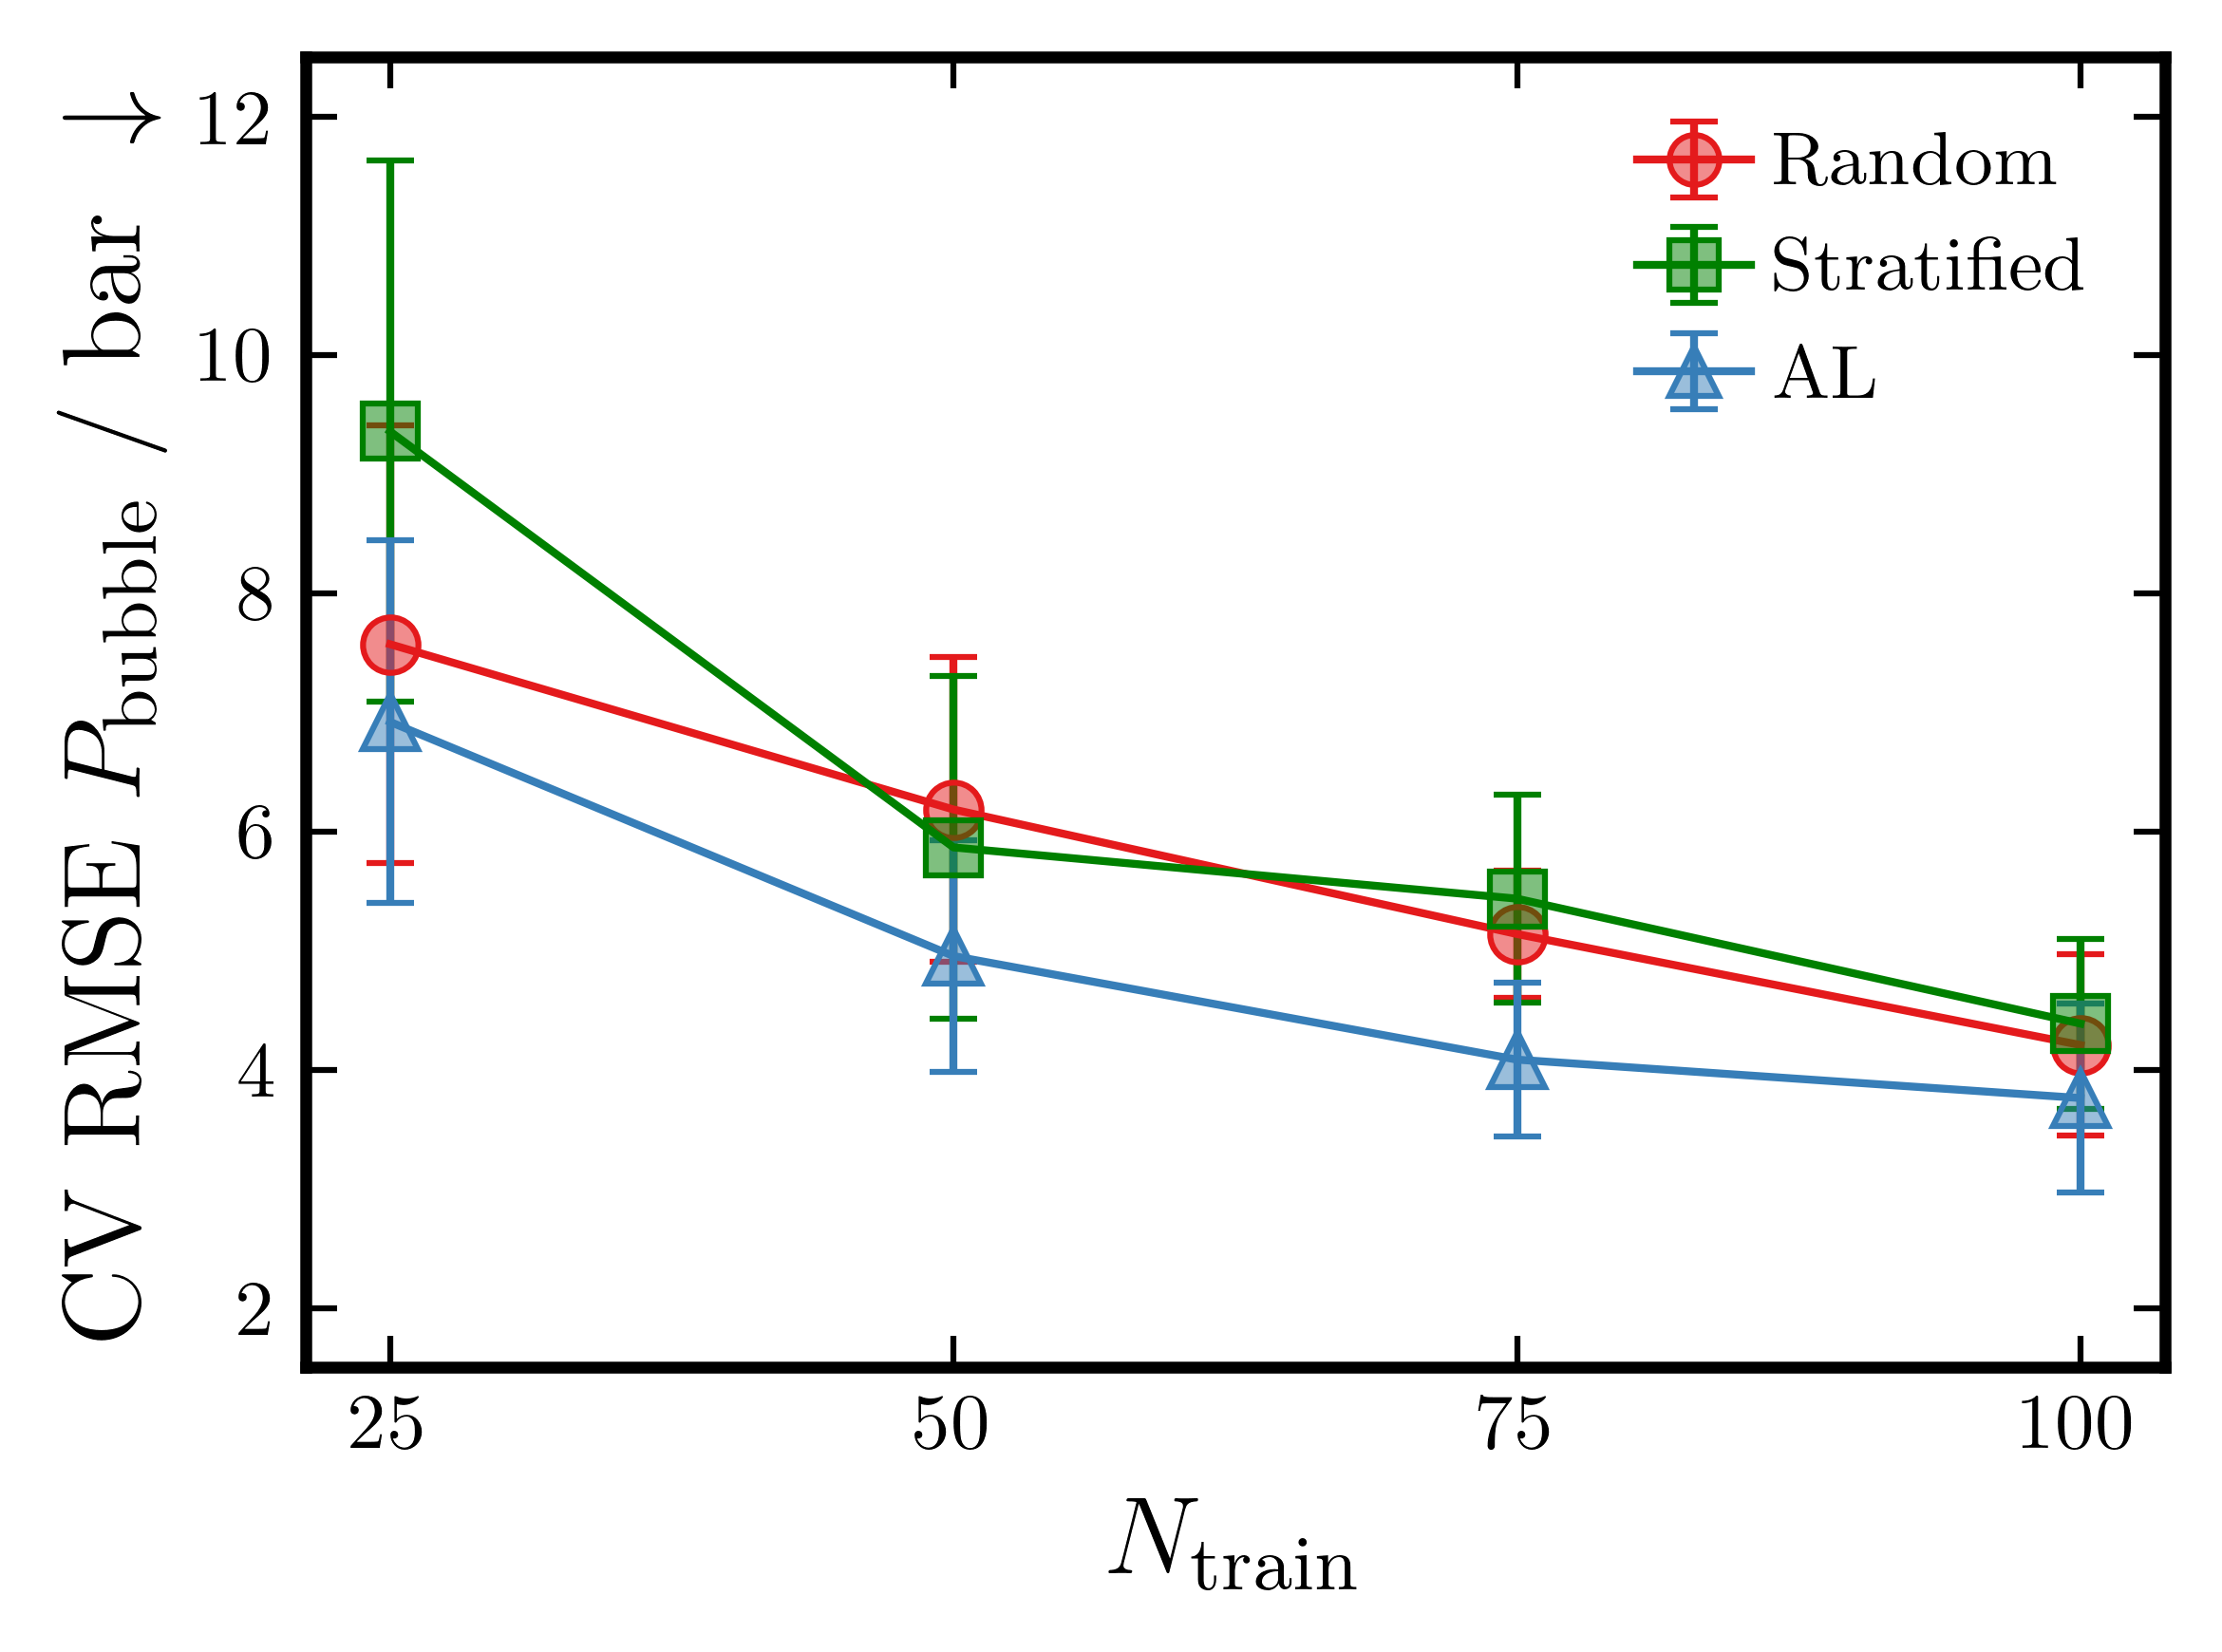

In [17]:
# CV RMSE — Pbubble
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(grp["N_train"].values, grp["rmse_y"].values, yerr=grp["rmse_err"].values,
               color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
               markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
               markerfacecolor=face_cycle[i], linewidth=linewidth, linestyle='-',
               capsize=capsize, label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ RMSE}\ P_{\mathrm{bubble}}\ /\ \mathrm{bar}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(1.5, 12.5)  # shared y-axis across TabPFN/XGB for P_bubble RMSE
ax.set_yticks(np.arange(2, 13, 2))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_RMSE_Pbubble", folder=os.path.join(BASE, "PLOTS"))
plt.show()


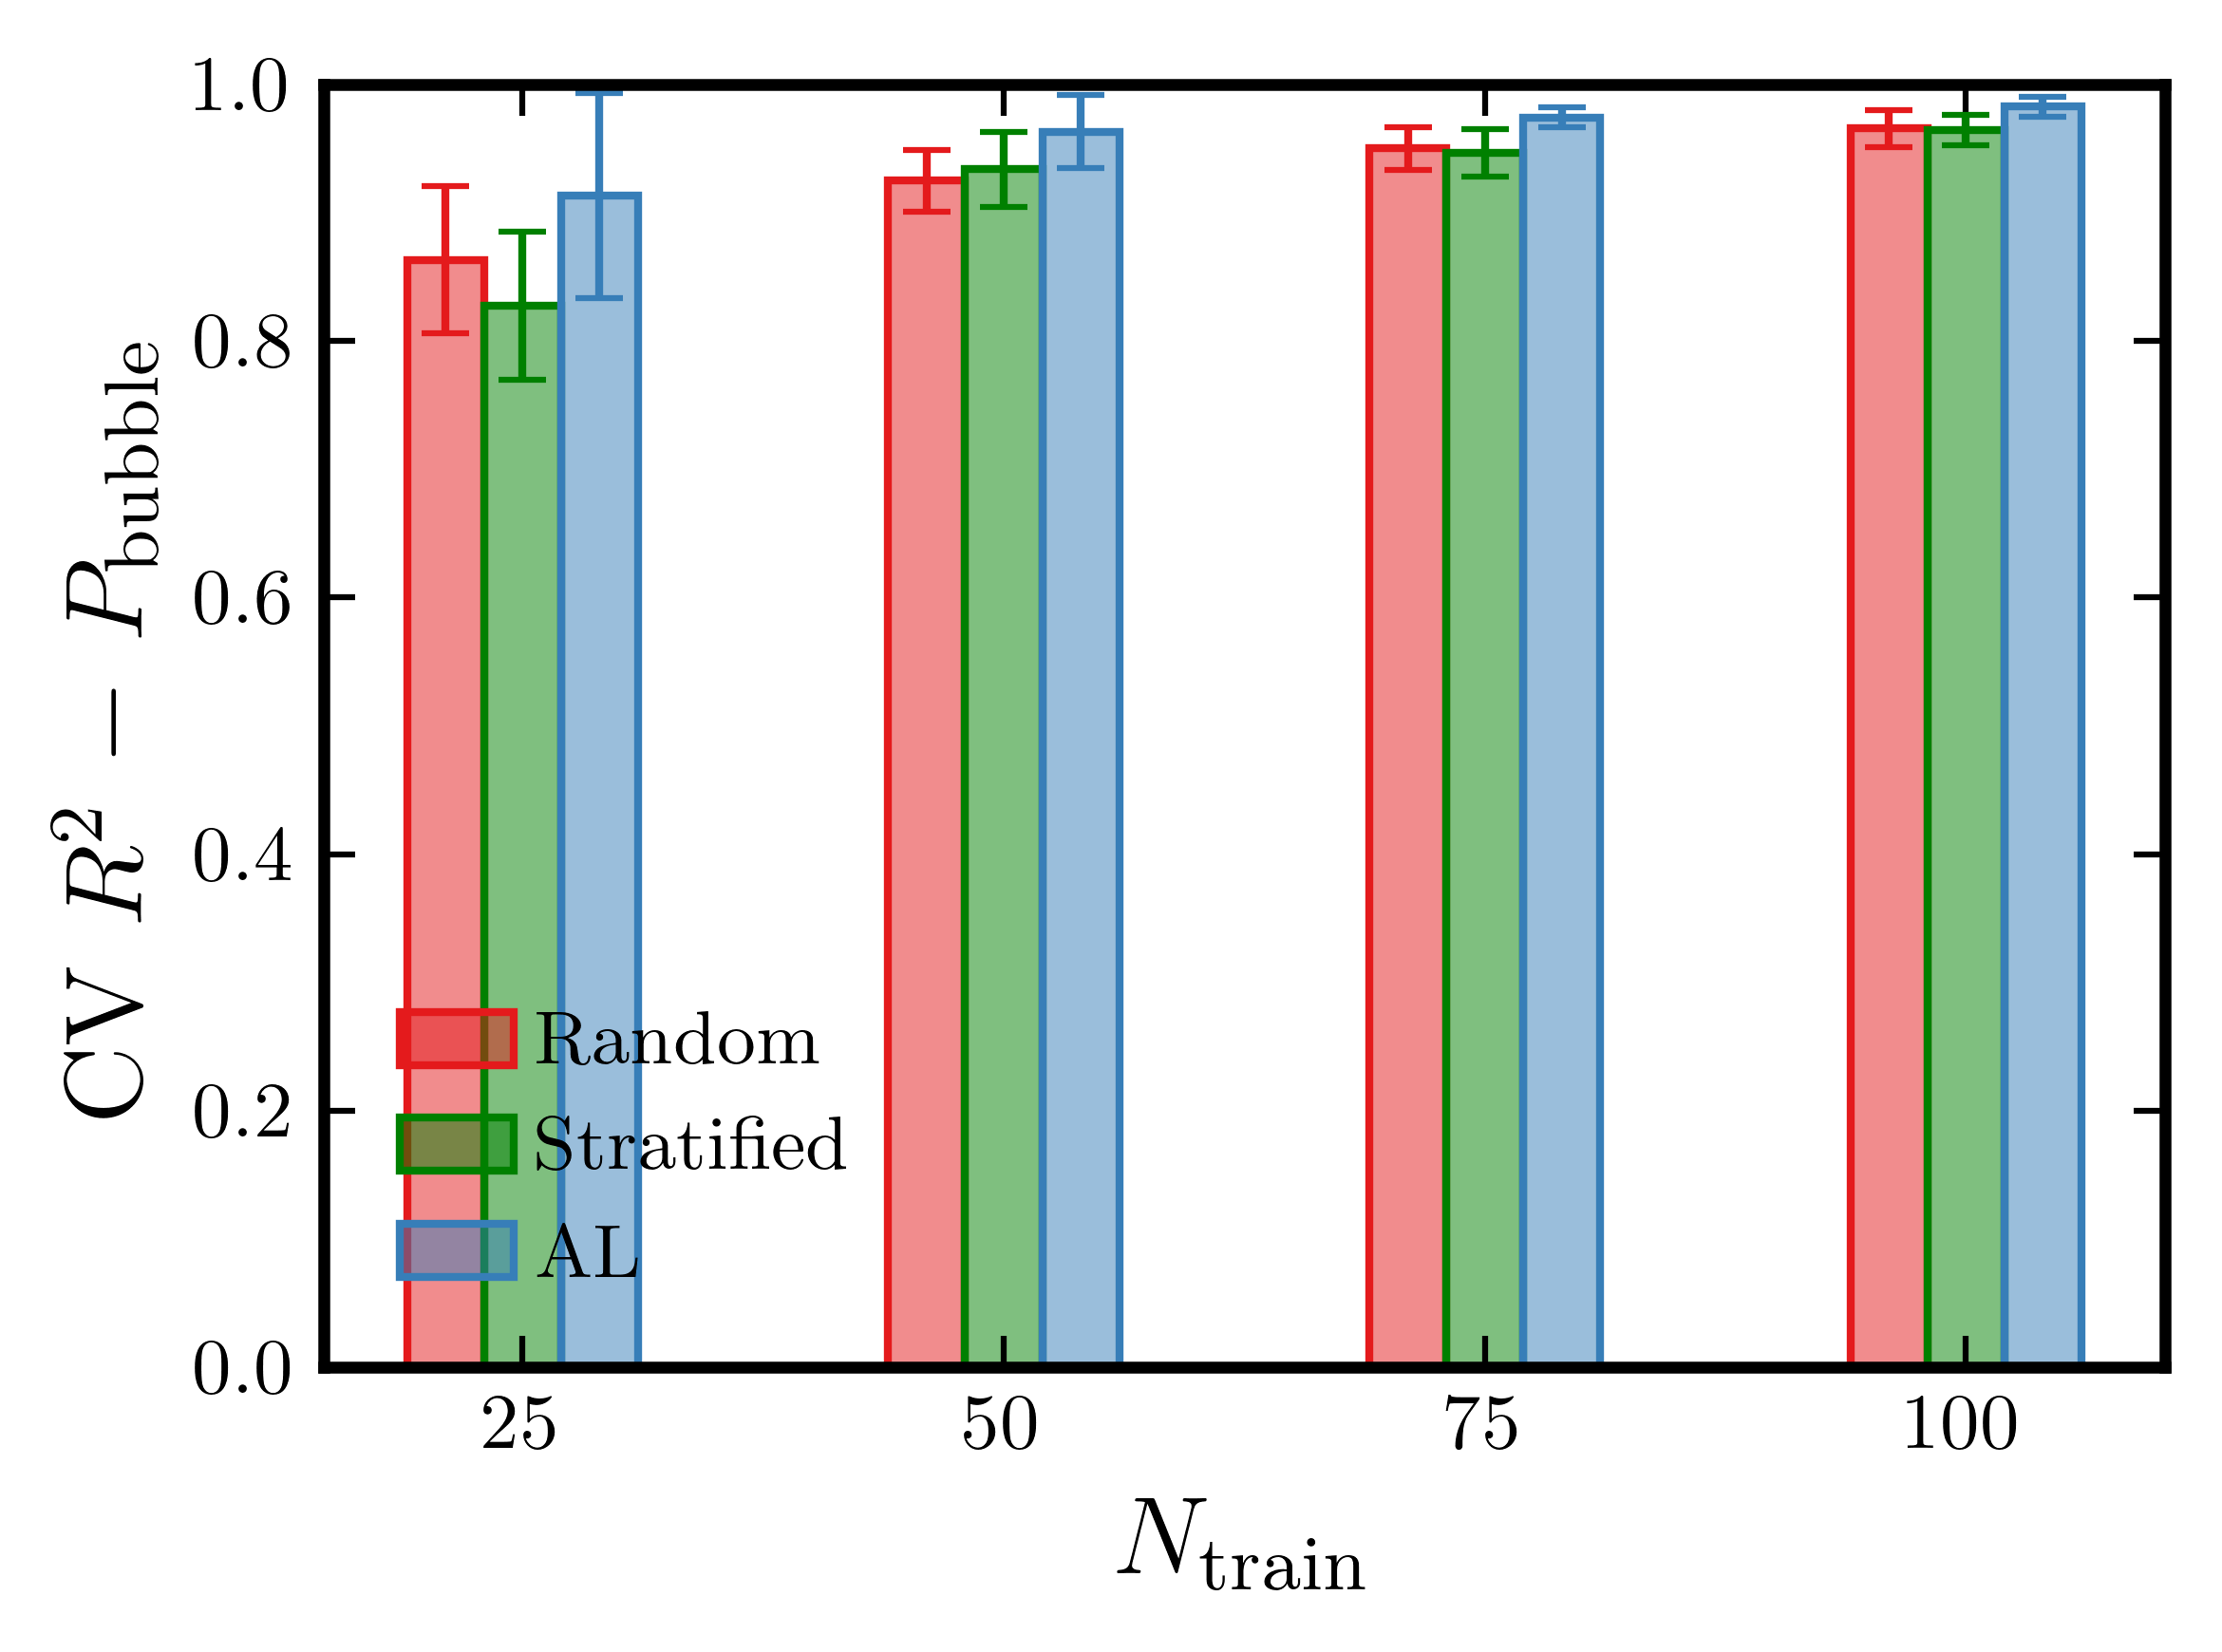

In [11]:
# CV R² — Pbubble
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    xs  = grp["N_train"].values
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * BAR_WIDTH
    ax.bar(xs + offset, grp["r2_y"].values, width=BAR_WIDTH,
           yerr=grp["r2_err"].values,
           color=face_cycle[i], edgecolor=color_cycle[i], linewidth=linewidth,
           capsize=capsize,
           error_kw={'elinewidth': linewidth, 'ecolor': color_cycle[i], 'capthick': markeredgewidth},
           label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV}\ R^{2}\ {-}\ P_{\mathrm{bubble}}$", fontsize=LABEL_FS)
ax.set_ylim(0, 1.0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_R2_Pbubble", folder=os.path.join(BASE, "PLOTS"))
plt.show()

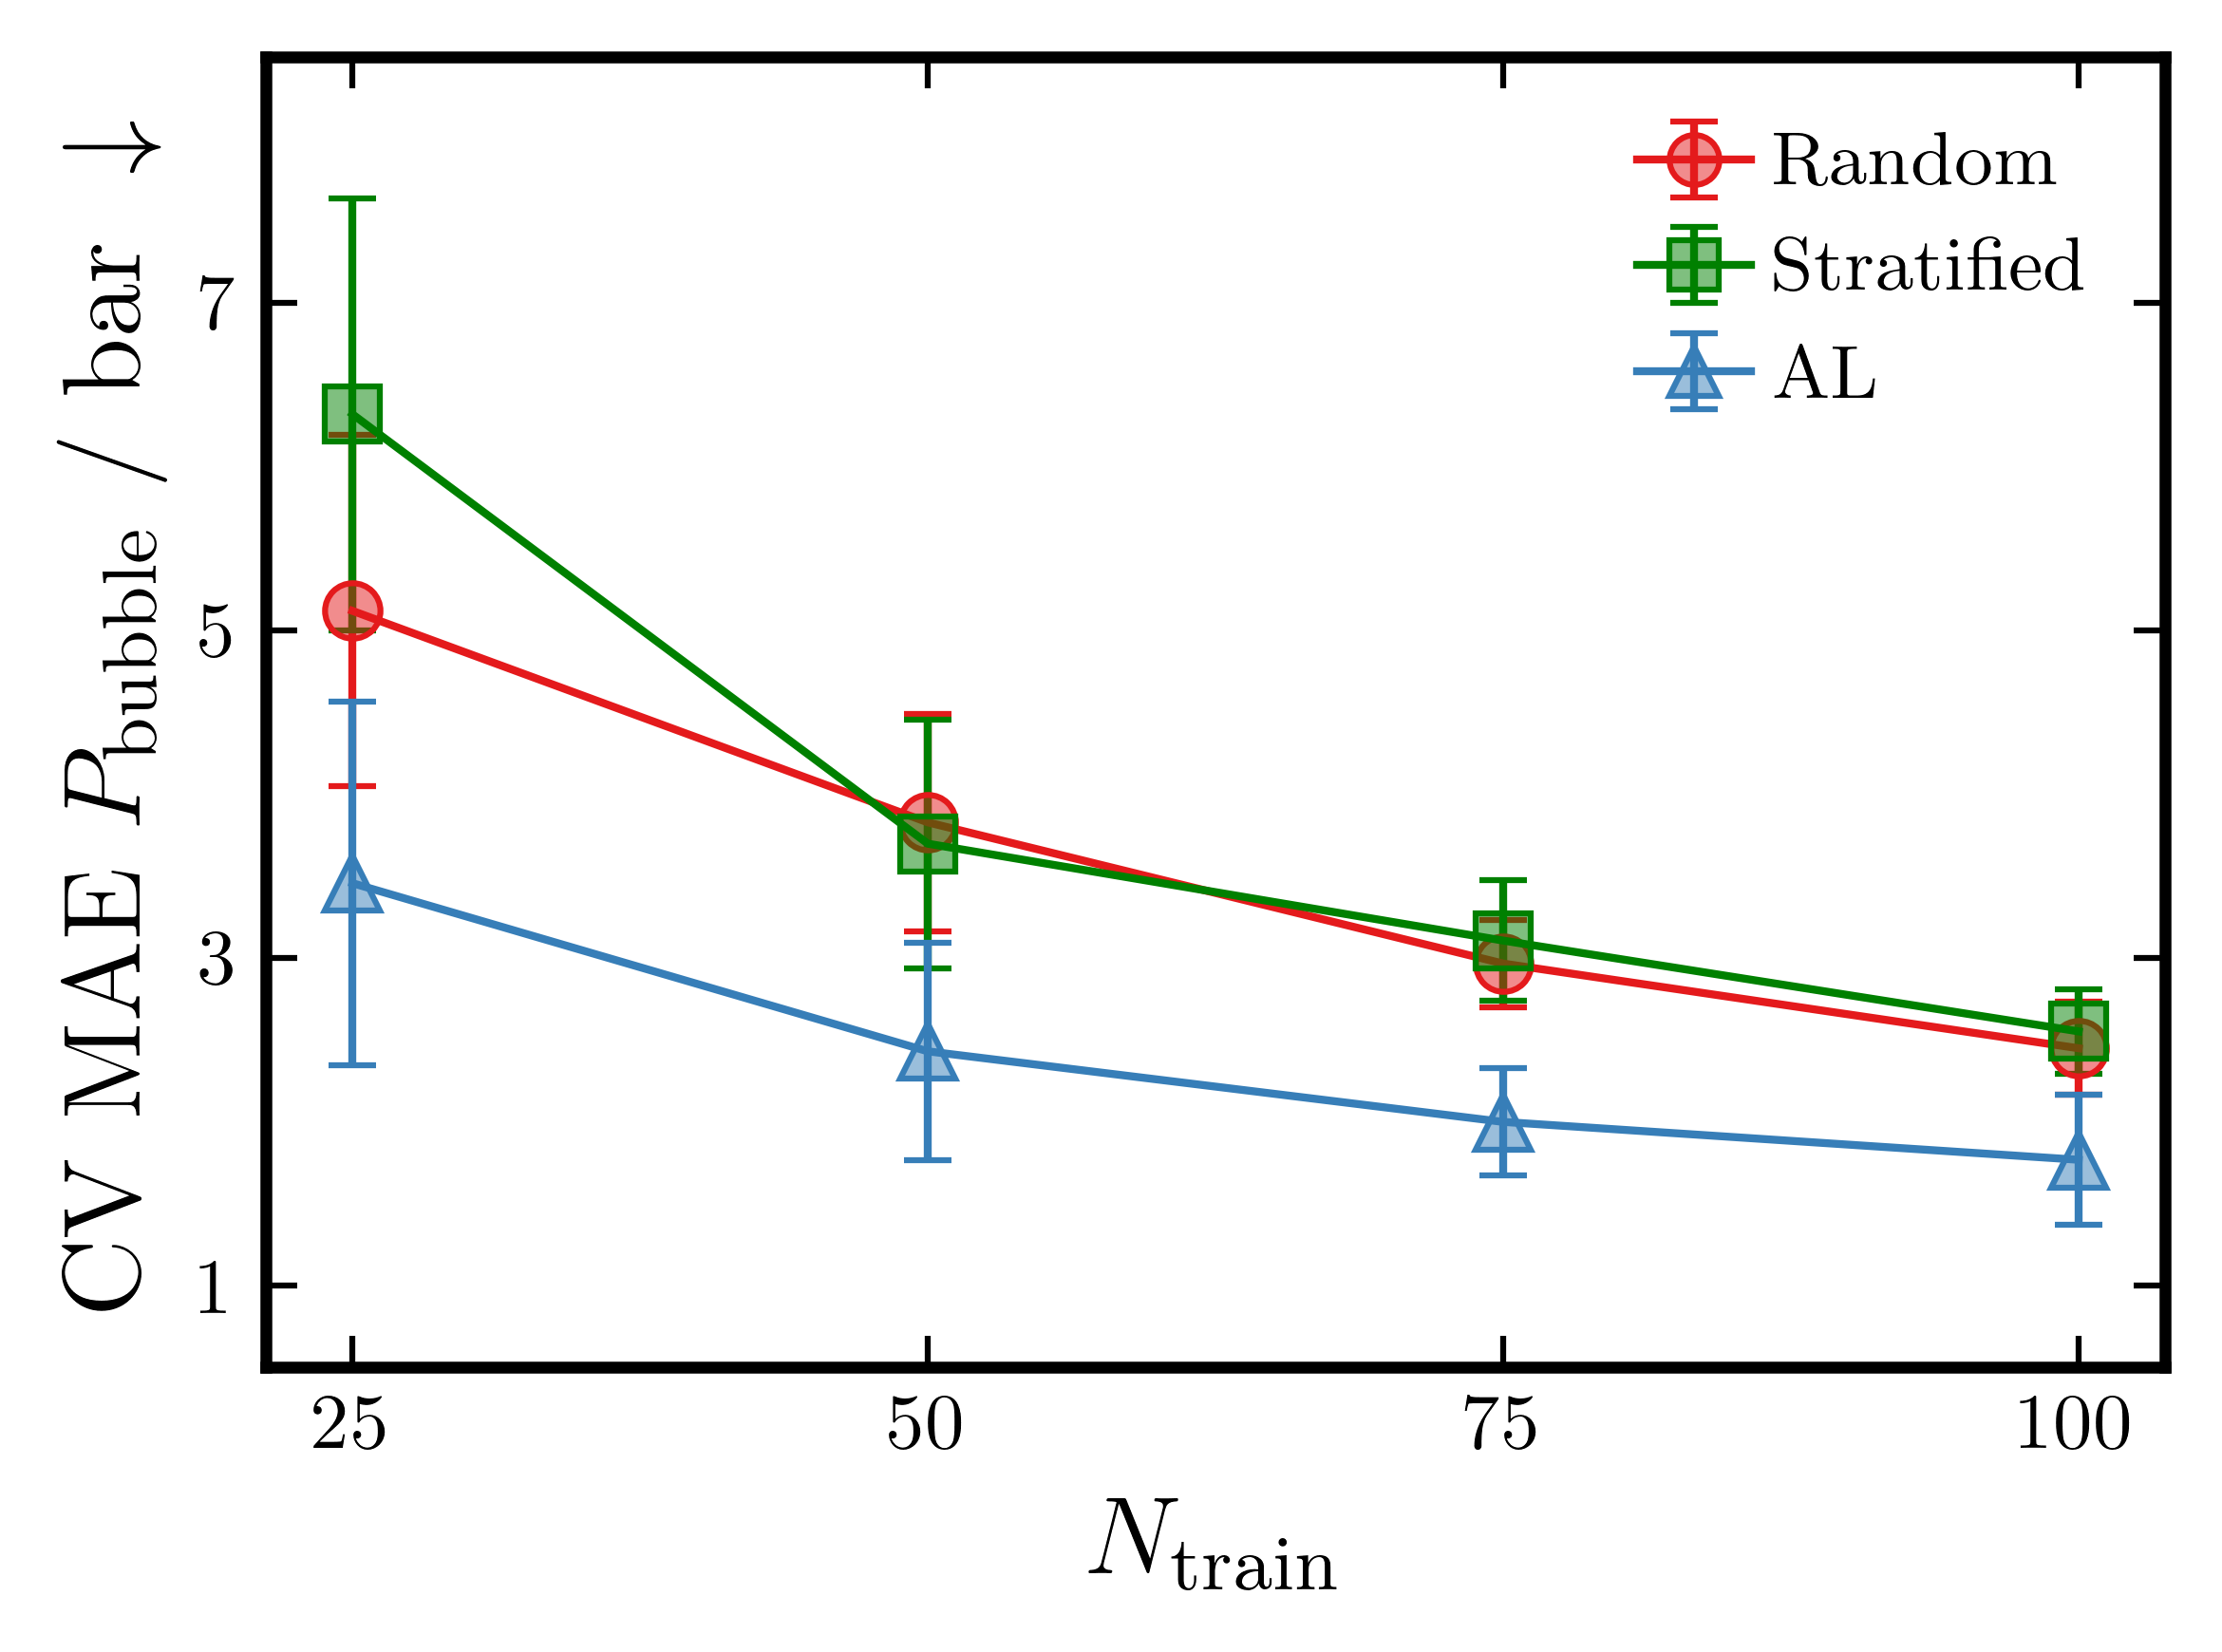

In [18]:
# CV MAE — Pbubble
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "P_bubble"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(grp["N_train"].values, grp["mae_y"].values, yerr=grp["mae_err"].values,
               color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
               markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
               markerfacecolor=face_cycle[i], linewidth=linewidth, linestyle='-',
               capsize=capsize, label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ MAE}\ P_{\mathrm{bubble}}\ /\ \mathrm{bar}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.5, 8.5)  # shared y-axis across TabPFN/XGB for P_bubble MAE
ax.set_yticks(np.arange(1, 9, 2))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_MAE_Pbubble", folder=os.path.join(BASE, "PLOTS"))
plt.show()


## γ (interfacial tension) plots

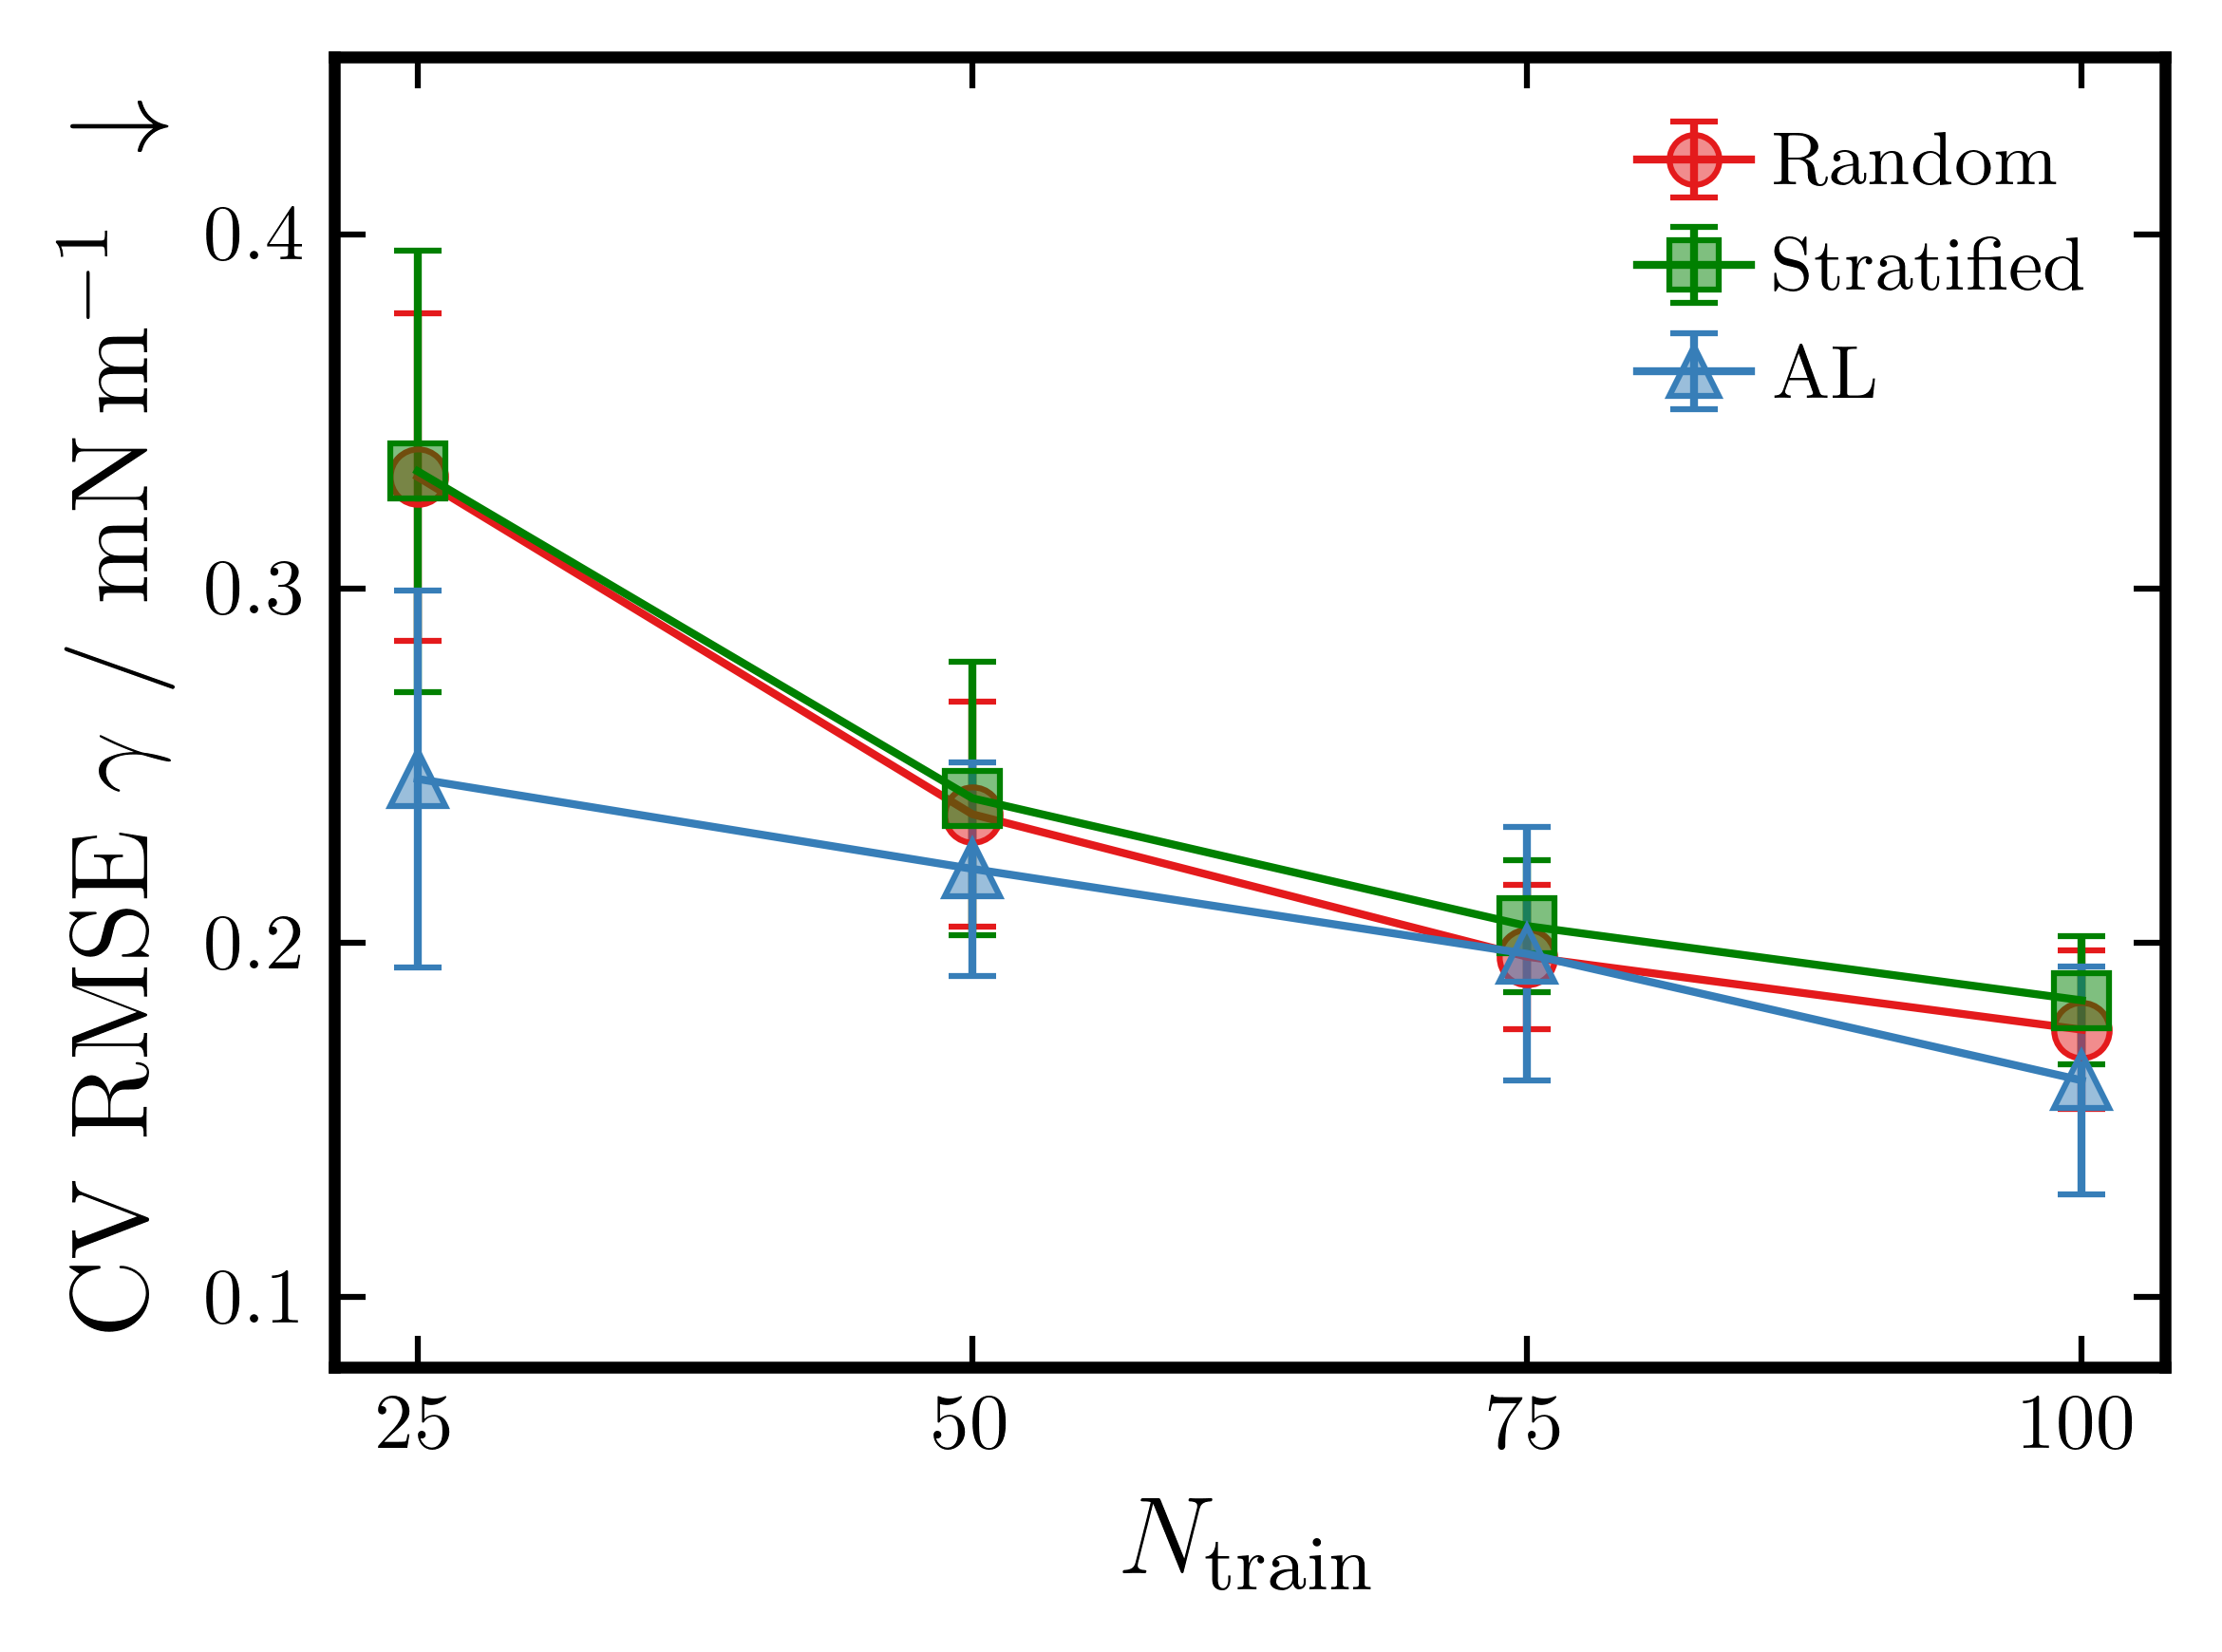

In [13]:
# CV RMSE — gamma
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(grp["N_train"].values, grp["rmse_y"].values, yerr=grp["rmse_err"].values,
               color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
               markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
               markerfacecolor=face_cycle[i], linewidth=linewidth, linestyle='-',
               capsize=capsize, label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ RMSE}\ \gamma\ /\ \mathrm{mN}\,\mathrm{m}^{-1}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.08, 0.45)  # shared y-axis across TabPFN/XGB for gamma RMSE
ax.set_yticks(np.arange(0.1, 0.45, 0.1))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_RMSE_gamma", folder=os.path.join(BASE, "PLOTS"))
plt.show()


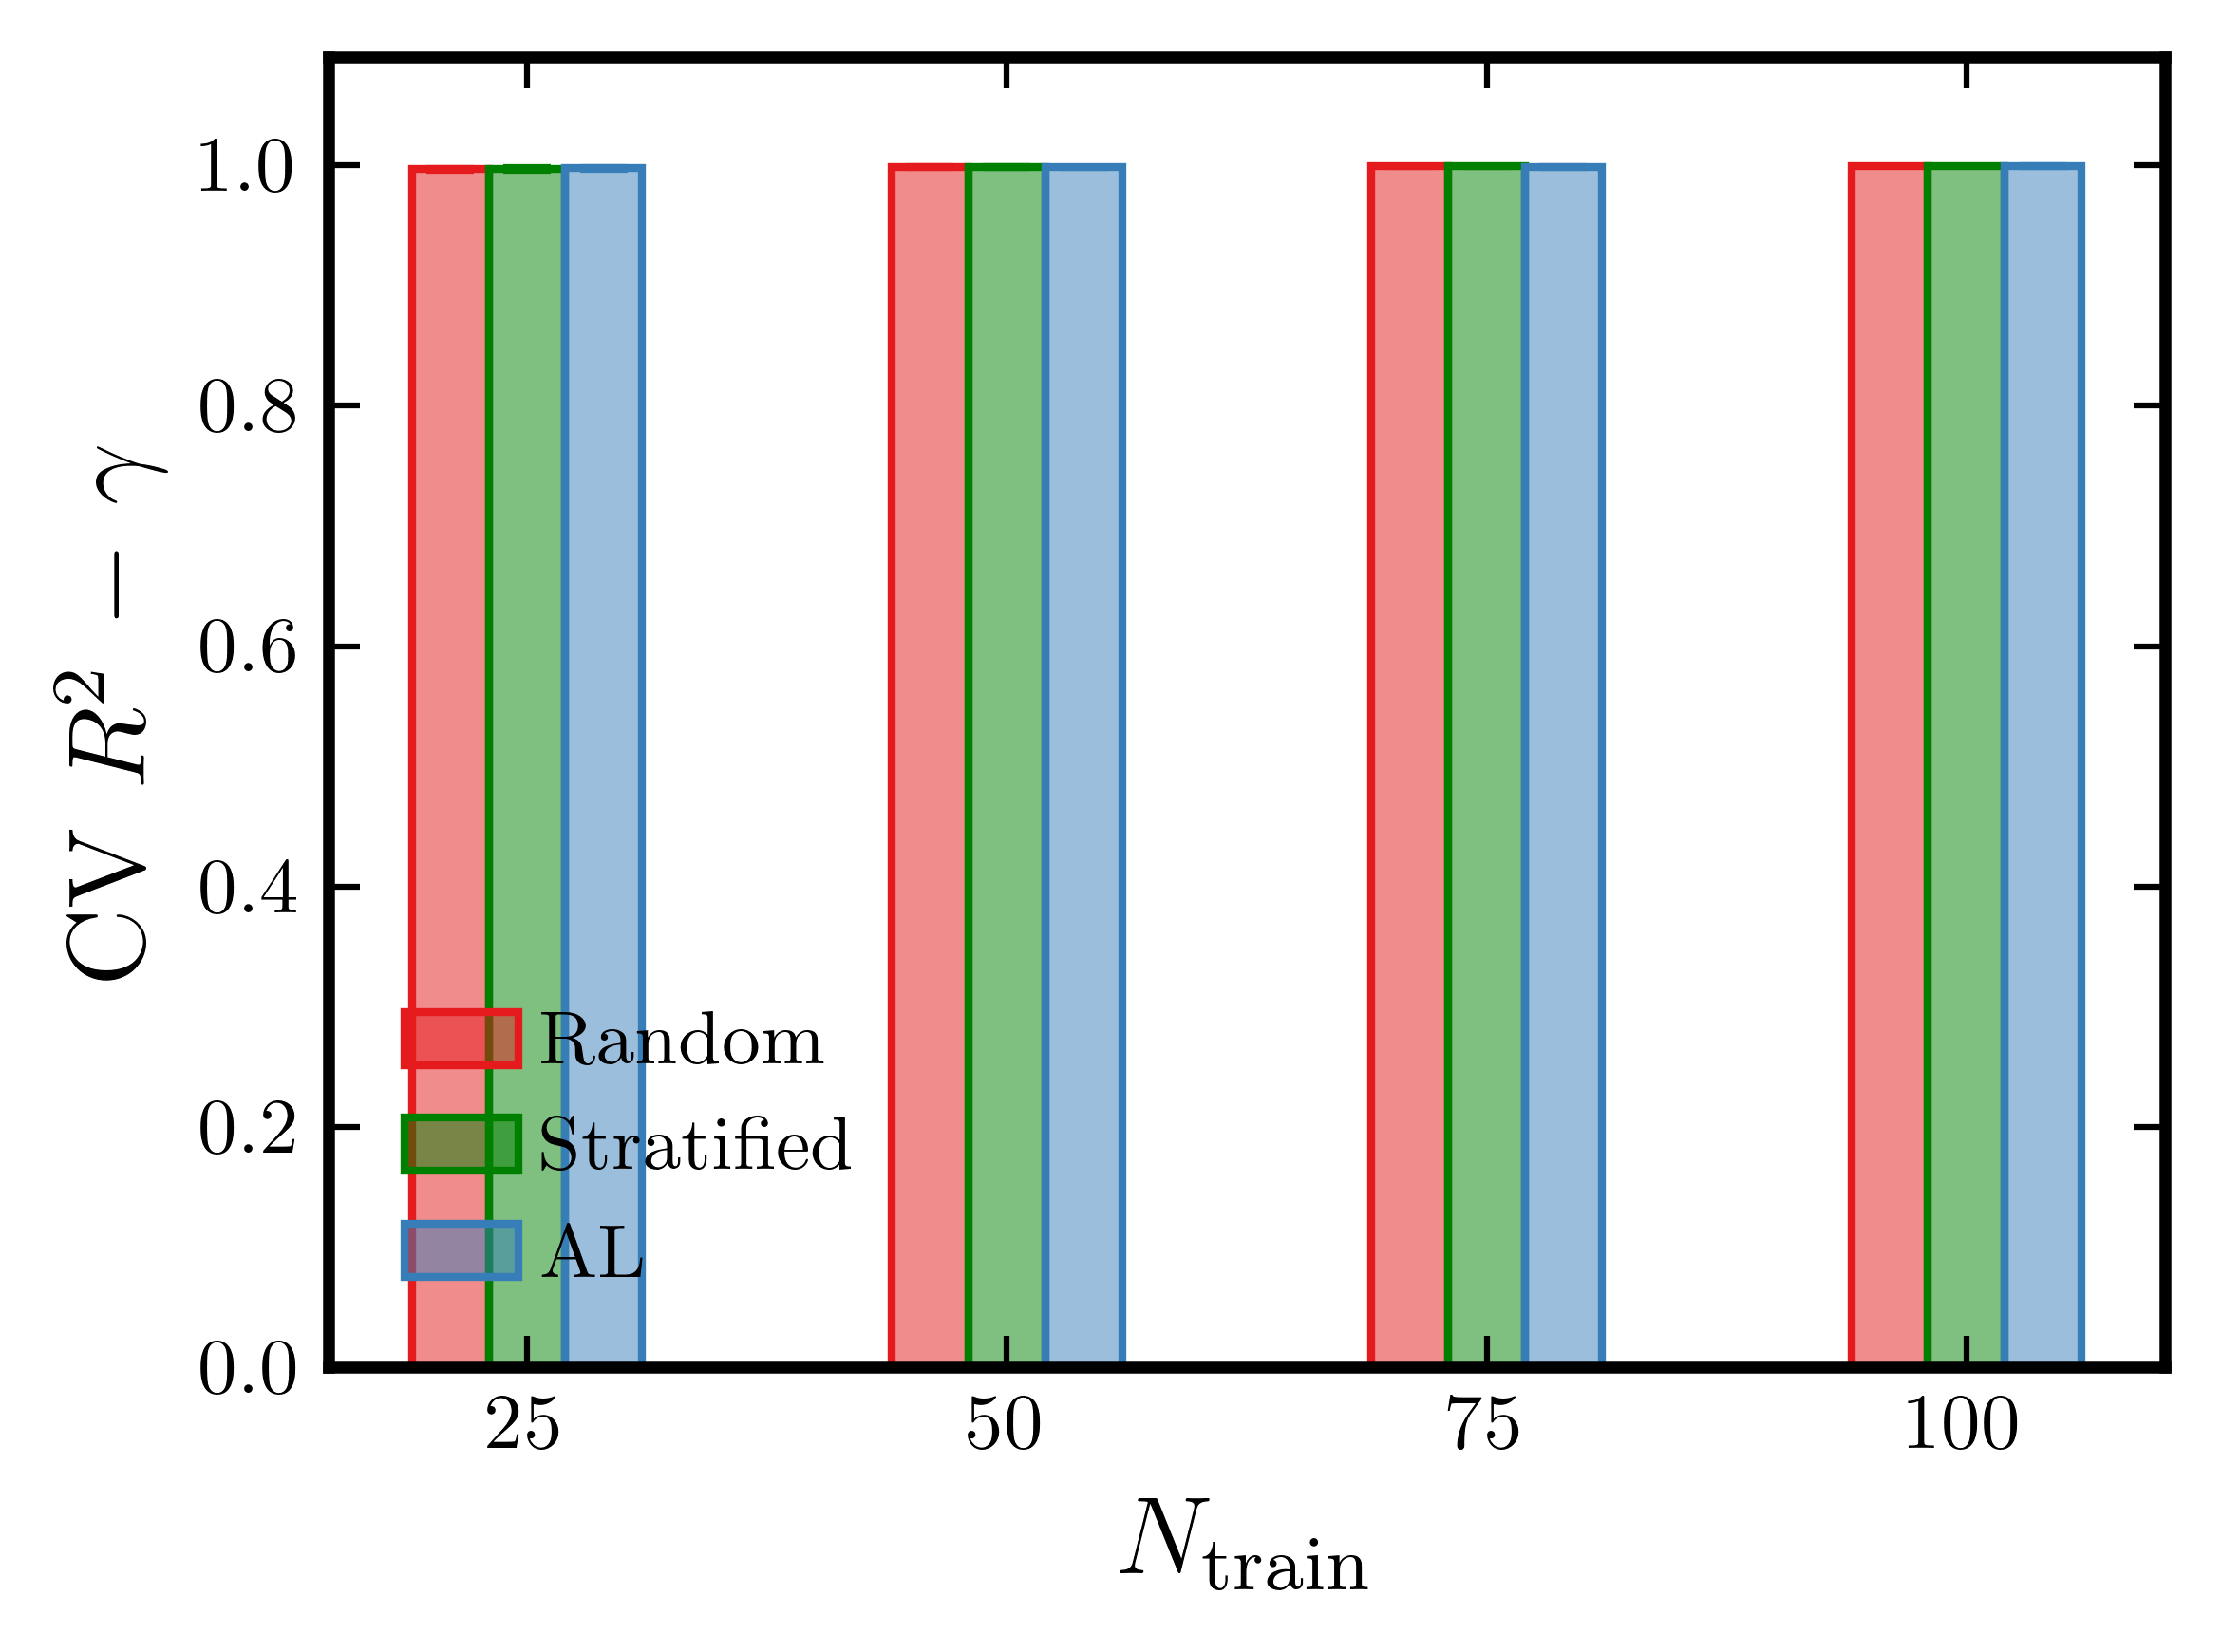

In [14]:
# CV R² — gamma
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    xs  = grp["N_train"].values
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * BAR_WIDTH
    ax.bar(xs + offset, grp["r2_y"].values, width=BAR_WIDTH,
           yerr=grp["r2_err"].values,
           color=face_cycle[i], edgecolor=color_cycle[i], linewidth=linewidth,
           capsize=capsize,
           error_kw={'elinewidth': linewidth, 'ecolor': color_cycle[i], 'capthick': markeredgewidth},
           label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV}\ R^{2}\ {-}\ \gamma$", fontsize=LABEL_FS)
ax.set_ylim(0, 1.09)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_R2_gamma", folder=os.path.join(BASE, "PLOTS"))
plt.show()

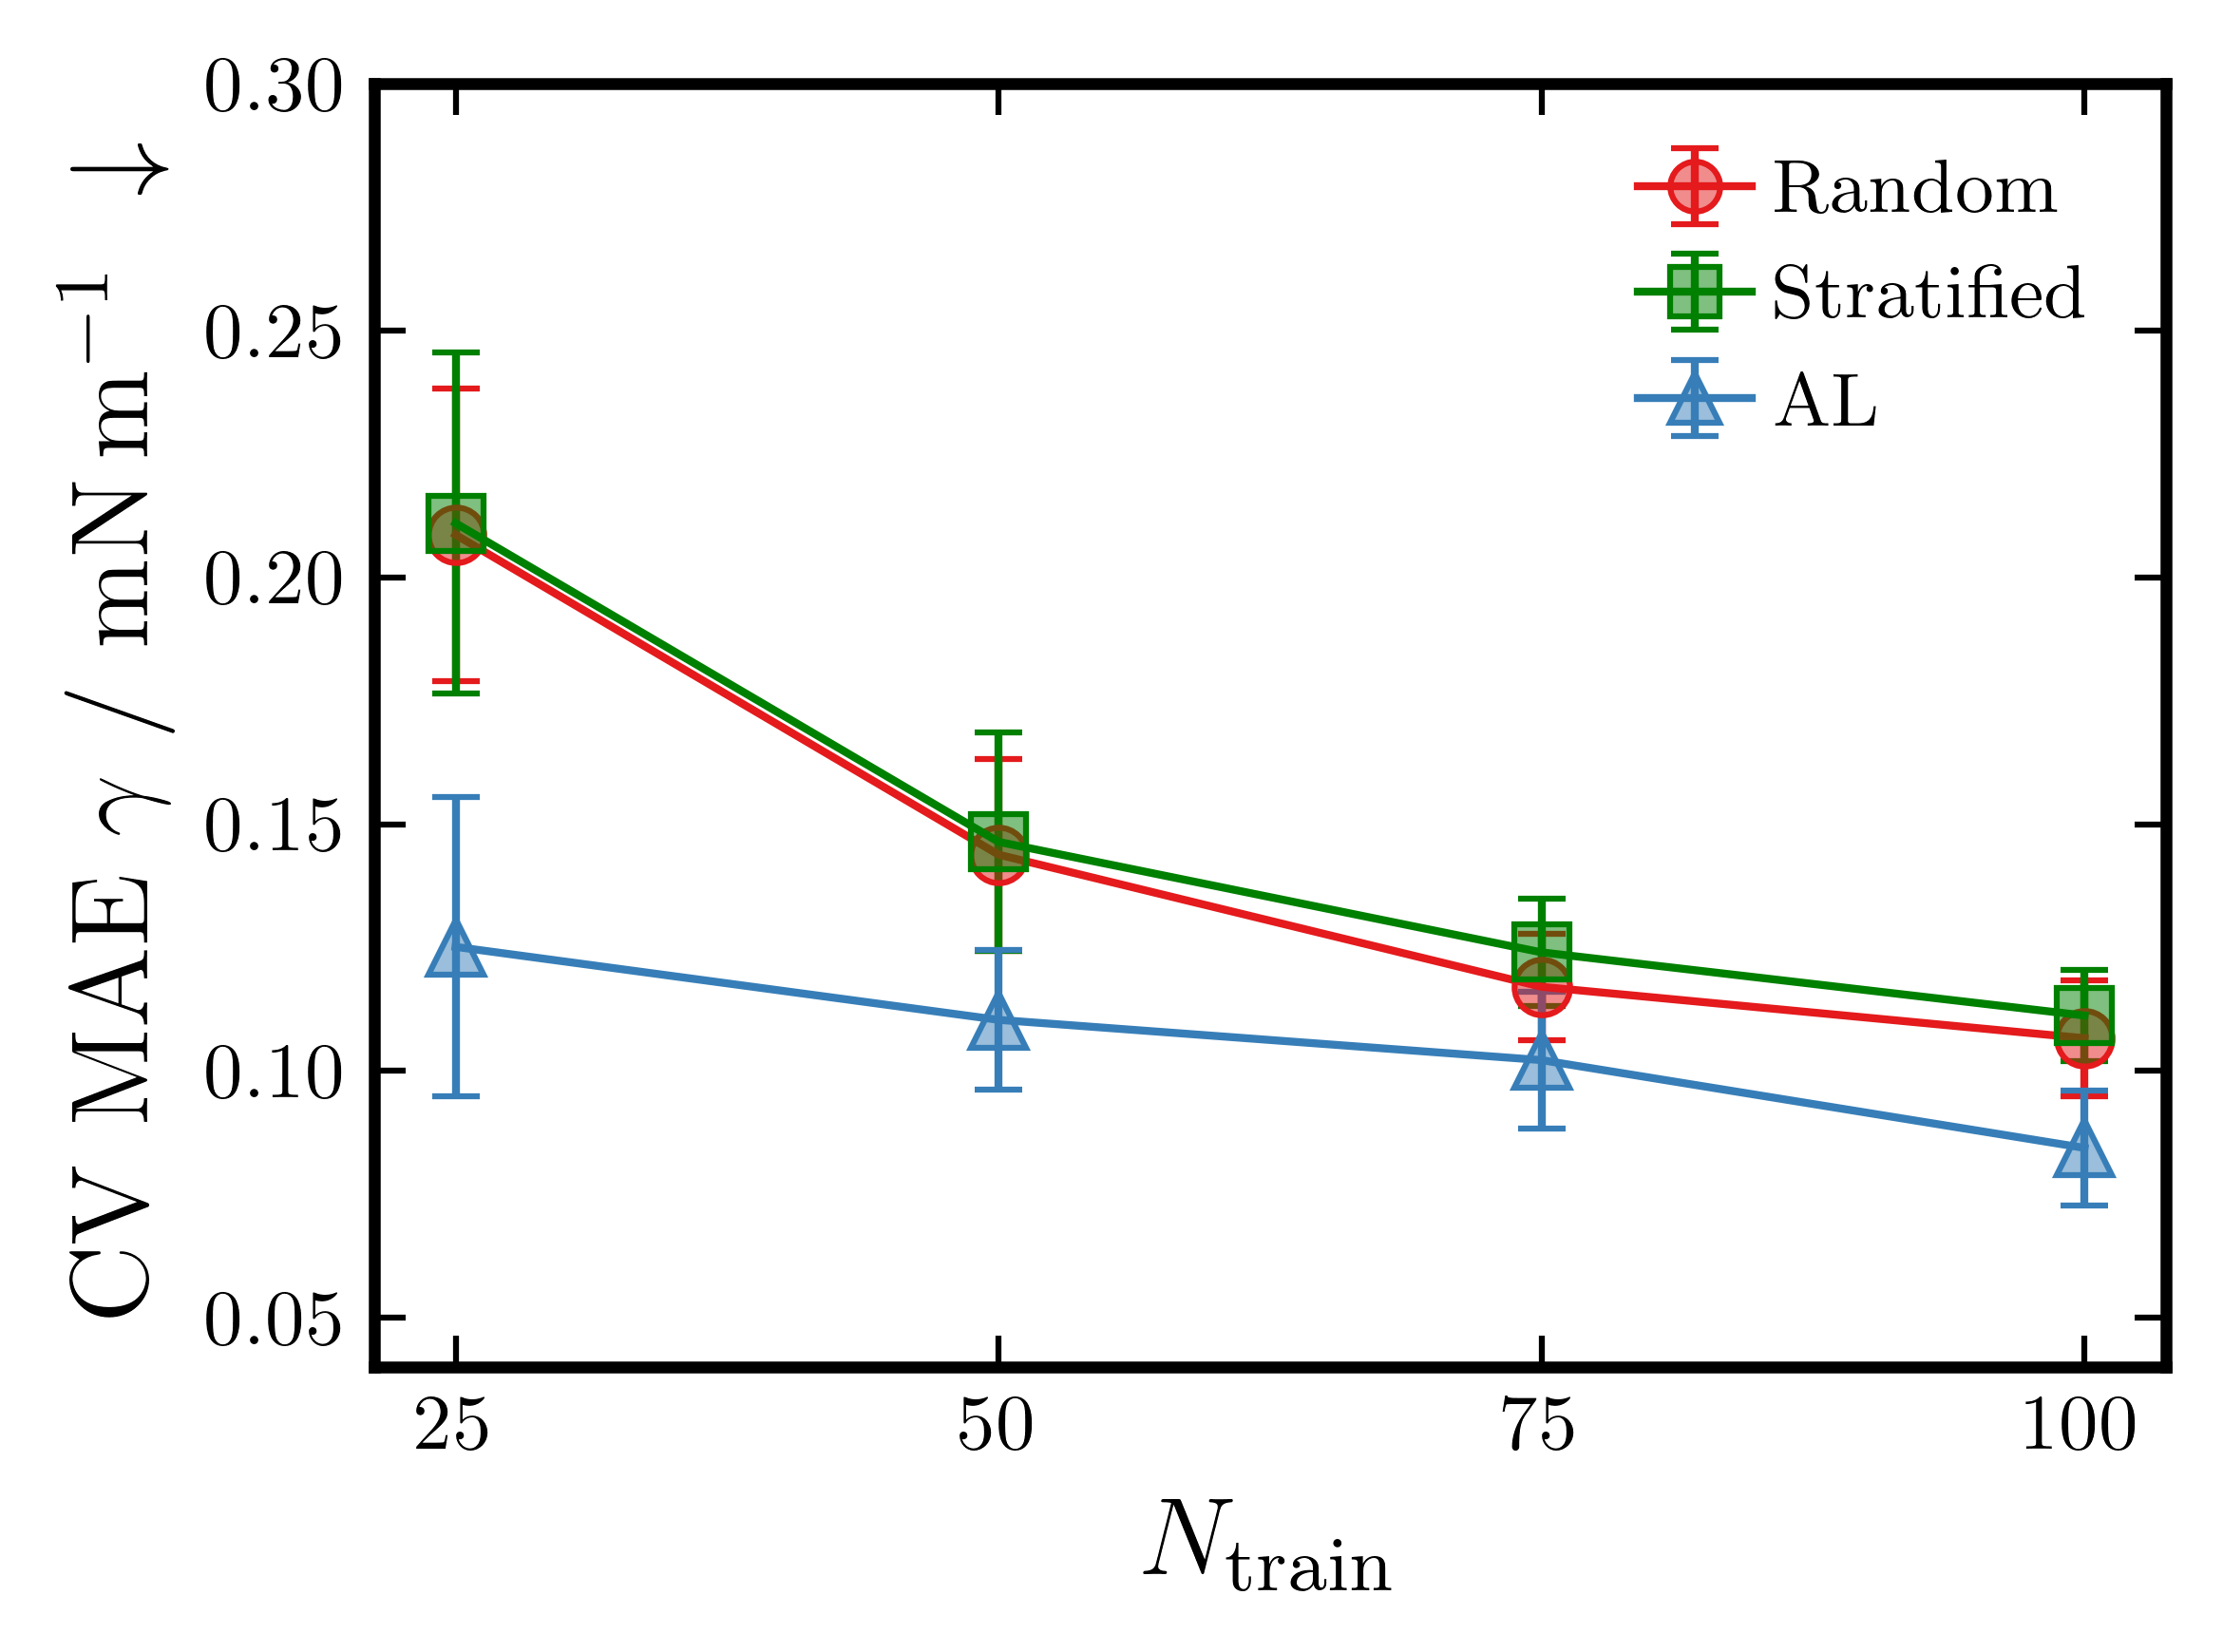

In [20]:
# CV MAE — gamma
fig, ax = plot_init(w=4, h=3)
sub = df_plot[df_plot["target"] == "gamma"]
for i, method in enumerate(METHOD_ORDER):
    grp = sub[sub["method"] == method].sort_values("N_train")
    ax.errorbar(grp["N_train"].values, grp["mae_y"].values, yerr=grp["mae_err"].values,
               color=color_cycle[i], marker=marker_cycle[i], markersize=markersize,
               markeredgewidth=markeredgewidth, markeredgecolor=color_cycle[i],
               markerfacecolor=face_cycle[i], linewidth=linewidth, linestyle='-',
               capsize=capsize, label=METHOD_LABELS[method])
ax.set_xticks(SIZES)
ax.set_xlabel(r"$N_{\mathrm{train}}$", fontsize=LABEL_FS)
ax.set_ylabel(r"$\mathrm{CV\ MAE}\ \gamma\ /\ \mathrm{mN}\,\mathrm{m}^{-1}\ \downarrow$", fontsize=LABEL_FS)
ax.set_ylim(0.04, 0.3)  # shared y-axis across TabPFN/XGB for gamma MAE
ax.set_yticks(np.arange(0.05, 0.31, 0.05))
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.tick_params(axis='both', which='major', labelsize=TICK_FS)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FormatStrFormatter(r"$%.2f$"))
apply_legend(ax)
fig.tight_layout()
save_plot(fig, "xgb_cv_MAE_gamma", folder=os.path.join(BASE, "PLOTS"))
plt.show()
